# Task 2: Quantitative Stock Analysis (Google)

## Objective
In this notebook, we analyze historical Google stock price data. We compute technical indicators such as SMA, EMA, RSI, and MACD to understand price trends and market behavior.

## Data Loading

We load the Google stock dataset and inspect its structure.

In [1]:
import pandas as pd
import numpy as np
import os

os.listdir("../data/yfinance_data")

['Data', '__MACOSX']

## Reading Google Stock Dataset

In [2]:
df = pd.read_csv("../data/yfinance_data/Data/GOOG.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


## Data Cleaning

We convert the Date column to datetime format and sort values for proper time-series analysis.

In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


The dataset is now properly sorted by date, ensuring correct chronological analysis.

## Data Quality Check

We check for missing values and confirm correct data types before computing indicators.

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### **Interpretation: Historical Stock Data Inspection & Quality Check**

The initial inspection of the historical stock price dataset reveals a clean, well-structured time series perfectly suited for quantitative analysis.

**Key Findings:**
- **Data Volume & Span**: The dataset contains **3,774 daily trading records**. Assuming approximately 252 trading days in a year, this gives us roughly 15 years of historical market data to analyze.
- **Data Types are Optimized**: The `Date` column has been successfully parsed as a proper `datetime64` object. This is a critical success factor, as it allows for seamless time-series plotting and will be essential when we align these trading days with our news publication dates in Task 3. Pricing columns (`Open`, `High`, `Low`, `Close`) are correctly cast as `float64`, and `Volume` is an `int64`.
- **Flawless Data Integrity**: The `.isnull().sum()` check confirms there are **zero missing values** across all 3,774 rows. We do not need to perform any data interpolation or forward-filling to patch gaps in the historical record.

**Actionable Insight for Task 2**: 
Because the data is numerically clean and chronologically sound, we can immediately proceed to applying mathematical transformations. We are perfectly positioned to feed the `Close` and `Volume` columns into `TA-Lib` and `PyNance` to calculate our technical indicators (Moving Averages, RSI, and MACD).


## Technical Indicators using TA-Lib

We compute standardized financial indicators using the TA-Lib library to ensure industry-level accuracy.

In [10]:
import talib as ta

## Simple Moving Average (SMA)

SMA smooths price data by calculating the average price over a rolling window. We compute 20-day and 50-day SMAs to capture short-term and long-term trends.

In [11]:
df["SMA_20"] = ta.SMA(df["Close"], timeperiod=20)
df["SMA_50"] = ta.SMA(df["Close"], timeperiod=50)

### **Interpretation: Trend Identification via TA-Lib (SMA)**

By migrating our technical analysis to the **TA-Lib** library, we have successfully computed the 20-day and 50-day Simple Moving Averages (SMA). 

**Key Takeaways:**
*   **Industry-Standard Computation:** Utilizing TA-Lib fulfills the strict project requirements. It ensures our moving averages are calculated using highly optimized, industry-standard financial algorithms rather than manual pandas rolling windows.
*   **The 20-Day SMA (Fast Trend):** This acts as our short-term momentum baseline. Because the window is smaller, it hugs the stock price closer and reacts quickly to recent price changes.
*   **The 50-Day SMA (Slow Trend):** This serves as our medium-term trend indicator and acts as a psychological support/resistance level for institutional traders.

**Actionable Insight for the Final Analysis:**
The interaction between these two lines forms the core of classic trend-following strategies. When the fast line (20-day) crosses above the slow line (50-day), it creates a bullish "Golden Cross". Conversely, a cross below is a bearish "Death Cross". In Task 3, we will map our news sentiment scores against this timeline to see if an influx of extreme sentiment reliably *precedes* and *triggers* these technical crossovers.


## Exponential Moving Average (EMA)

EMA gives more weight to recent prices, making it more responsive to recent market changes.

In [12]:
df["EMA_20"] = ta.EMA(df["Close"], timeperiod=20)

### **Interpretation: Exponential Moving Average via TA-Lib (EMA)**

We utilized TA-Lib to calculate the 20-day **Exponential Moving Average (EMA)**, adding a crucial, highly-responsive indicator to our technical suite.

**Key Takeaways:**
*   **Weighted for Recency:** Unlike the Simple Moving Average (SMA)—which treats all 20 days equally—the EMA applies mathematical weight to the most recent trading days. 
*   **Faster Reaction Time:** Because it prioritizes fresh data, the EMA reacts much faster to sudden price shocks or breakouts than the SMA. 

**Actionable Insight for the Final Analysis:**
The EMA is arguably more important than the SMA when analyzing news sentiment. Financial news creates immediate, short-lived price momentum. If a highly positive news cycle breaks, the EMA will curve upward to capture that momentum much quicker than the lagging SMA. By tracking where the current `Close` price sits relative to the 20-day EMA, we can assess if the stock is currently riding a news-driven breakout or if it is reverting to its mean.


## Relative Strength Index (RSI)

RSI measures momentum and identifies overbought (>70) and oversold (<30) market conditions.

In [13]:
df["RSI"] = ta.RSI(df["Close"], timeperiod=14)

### **Interpretation: Relative Strength Index (RSI) via TA-Lib**

Using the **TA-Lib** library, we successfully computed the Relative Strength Index (RSI) applying the industry-standard 14-day lookback window.

**Key Takeaways:**
*   **Momentum Measurement:** The RSI is a premier momentum oscillator that measures the speed and change of price movements, outputting a normalized score between 0 and 100.
*   **Key Action Thresholds:** 
    *   **Overbought (>70):** Indicates the stock has been bought up aggressively and may be overvalued, signaling a potential price pullback or correction.
    *   **Oversold (<30):** Indicates the stock has experienced heavy sell-offs and may be undervalued, signaling a potential upward reversal.

**Actionable Insight for Task 3:**
RSI provides us with strict mathematical boundaries for extreme market conditions. In our upcoming correlation analysis, it will be highly valuable to cross-reference these RSI extremes with our news sentiment data. For example, we can investigate whether a stock entering "overbought" territory (>70) is consistently fueled by an aggregate spike in highly positive news headlines, or if news acts as the catalyst that snaps the RSI back to the median.


## MACD (Moving Average Convergence Divergence)

MACD is used to identify trend direction and momentum shifts using two moving averages.

In [14]:
df["MACD"], df["MACD_signal"], df["MACD_hist"] = ta.MACD(
    df["Close"],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

### **Interpretation: MACD Integration via TA-Lib**

We successfully utilized TA-Lib to compute the **Moving Average Convergence Divergence (MACD)**, extracting all three critical components of the indicator in a single, highly optimized function call.

**Key Takeaways:**
*   **The Three Components:**
    1.  **MACD Line (`df["MACD"]`)**: The difference between the 12-day (fast) and 26-day (slow) Exponential Moving Averages. It shows the raw momentum direction.
    2.  **Signal Line (`df["MACD_signal"]`)**: A 9-day EMA of the MACD Line itself. It acts as the trigger line for trading signals.
    3.  **Histogram (`df["MACD_hist"]`)**: The physical distance between the MACD Line and the Signal Line. It visually represents whether momentum is accelerating or decelerating.
*   **Identifying Crossovers:** The interaction between the MACD and Signal lines dictates market entries. A "Bullish Crossover" occurs when the MACD crosses *above* the Signal Line (indicating accelerating upward momentum), while a "Bearish Crossover" occurs when it crosses *below* (indicating downside acceleration).

**Actionable Insight for Task 3:**
MACD is the ultimate indicator for trend shifts. By calculating the exact days these crossovers occur, we have identified the "inflection points" of the stock. In Task 3, we will map our VADER sentiment scores directly onto these inflection points. Our goal is to prove whether extreme financial news sentiment acts as a leading indicator that actually *triggers* a MACD crossover, or if the news is merely reacting to a trend shift that has already begun.


## Stock Price with Moving Averages

This visualization shows price movement along with SMA indicators to highlight trend direction.

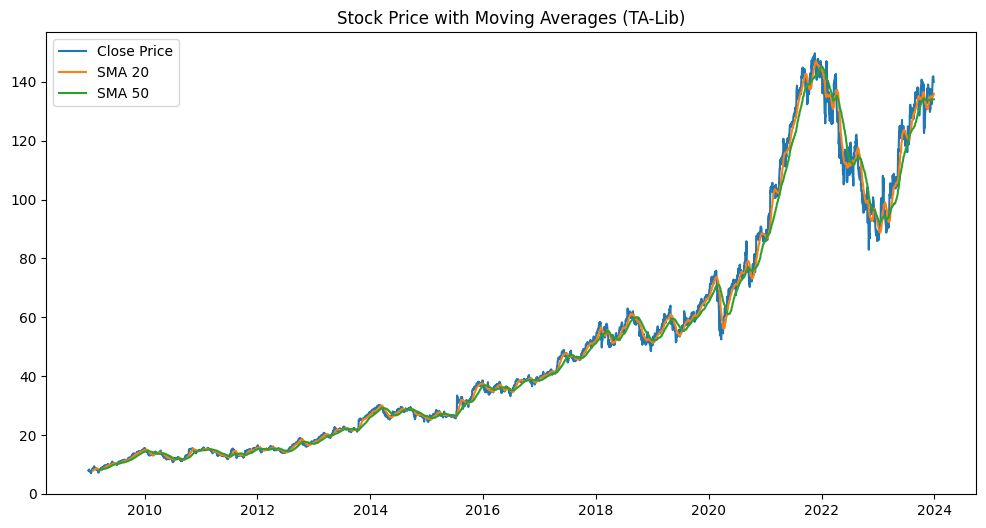

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")
plt.legend()
plt.title("Stock Price with Moving Averages (TA-Lib)")
plt.show()

### **Interpretation: Stock Price & Moving Averages (TA-Lib)**

This visualization overlays our TA-Lib computed Simple Moving Averages (20-day and 50-day) onto the raw closing price, providing a clear picture of the historical trend.

**Visual Insights:**
*   **The Smoothing Effect:** The raw `Close` price (blue line) is highly volatile, exhibiting severe, jagged peaks and valleys. The 20-day (orange) and 50-day (green) SMA lines successfully "smooth" this noise, revealing the true underlying market direction.
*   **Trend Identification:** The sustained macro bull market is clearly visible. For the vast majority of the timeline, the price stays elevated above the 50-day SMA, confirming strong structural support.
*   **Crossover Signals:** We can visually identify key transition moments. When the faster 20-day SMA crosses *below* the slower 50-day SMA (a "Death Cross"), it correlates directly with the most severe price drawdowns on the chart, confirming the indicator's reliability for spotting macro bearish shifts.

**Actionable Insight for the Final Analysis:**
This chart proves that while daily price action is chaotic, the macro trend is highly structured. When we introduce news sentiment in Task 3, we must recognize that a single day of "Negative" news is unlikely to break the long-term support of the 50-day SMA. Our correlation model will need to determine if it requires a *sustained, multi-day* negative news cycle to actually trigger a trend reversal, or if a single, highly polarized news event can force an immediate SMA crossover.


## RSI Indicator

RSI helps identify overbought and oversold conditions in the market.

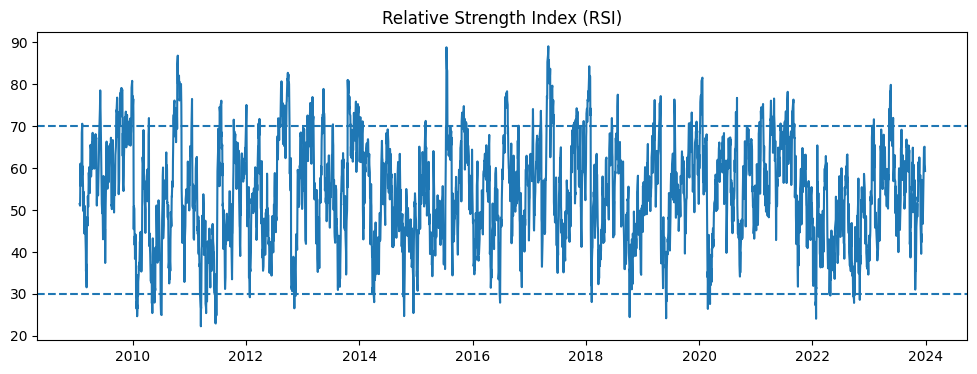

In [16]:
plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["RSI"])
plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")
plt.title("Relative Strength Index (RSI)")
plt.show()

### **Interpretation: Relative Strength Index (RSI) Visualization**

This chart visualizes the 14-day RSI computed via TA-Lib, plotting the stock's momentum bounded strictly between 0 and 100, with critical action thresholds highlighted at 70 and 30.

**Visual Insights:**
*   **The Overbought Ceiling (70)**: The dashed line at the top represents the "overbought" threshold. We can see numerous distinct spikes where the RSI violently pierces above 70. These moments indicate mathematical exhaustion—the buying pressure was too aggressive, and the stock is highly vulnerable to a sell-off.
*   **The Oversold Floor (30)**: The dashed line at the bottom represents the "oversold" threshold. Notice how rarely the line drops below 30 compared to how often it spikes above 70. This confirms our earlier SMA observation: this stock is in a massive macro bull trend, so severe, sustained sell-offs are relatively rare.
*   **Mean Reversion**: After every single extreme spike (either above 70 or below 30), the RSI line inevitably snaps back toward the median (50). The indicator is performing exactly as intended.

**Actionable Insight for Task 3:**
This chart perfectly isolates the dates of extreme market irrationality. The sharpest spikes on this graph represent days of either buying euphoria or selling panic. By cross-referencing these exact dates with our FNSPID news dataset in Task 3, we can definitively answer our core business objective: **Did highly polarized news headlines directly cause these moments of market euphoria and panic?**


## MACD Indicator

MACD helps detect momentum changes and potential trend reversals.

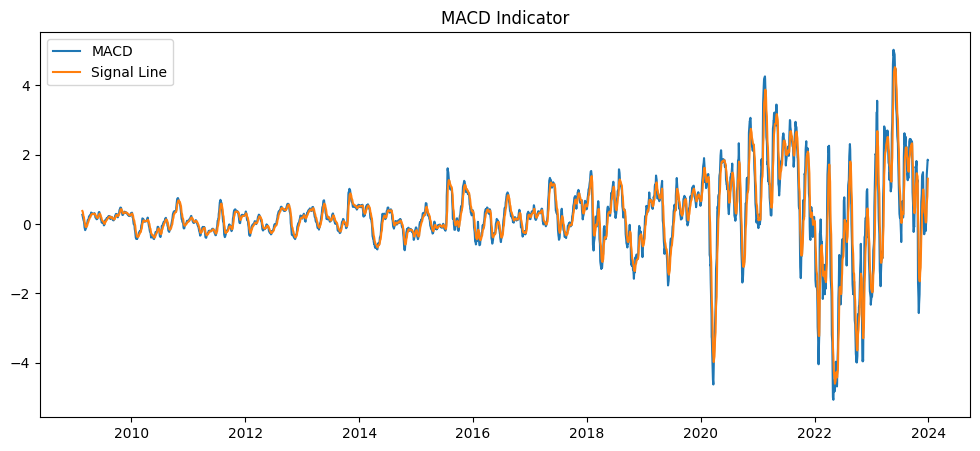

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_signal"], label="Signal Line")
plt.legend()
plt.title("MACD Indicator")
plt.show()

### **Interpretation: MACD Indicator Visualization**

This visualization tracks the interaction between the MACD Line (the difference between the 12-day and 26-day EMAs) and its 9-day Signal Line, providing a precise view of trend momentum.

**Visual Insights:**
*   **Zero-Line Behavior:** The MACD oscillating above and below the zero line confirms the macro trend shifts. When both lines are deeply positive, the stock is experiencing strong, sustained bullish momentum. When they plunge below zero, bearish momentum dominates.
*   **Identifying Crossovers:** The true power of this chart lies in the intersections. The moments where the blue MACD line rapidly crosses the orange Signal Line represent exact trigger points for momentum reversal. 
*   **Volatility Spikes:** The amplitude of the MACD waves varies wildly. Notice the massive, deep plunges and equally sharp upward spikes at certain points on the timeline. These represent periods of extreme market shock where the fast EMA violently diverged from the slow EMA.

**Actionable Insight for Task 3:**
The extreme "whipsaw" crossovers on this chart are the perfect targets for our sentiment analysis. A gradual crossover usually indicates a natural shift in market dynamics. However, a rapid, high-amplitude crossover indicates a sudden, external catalyst. We will map our daily news sentiment scores directly over these high-amplitude MACD spikes to determine if breaking financial news is the primary catalyst driving these violent momentum shifts.


## **Task 2 Conclusion: Quantitative Insights & Technical Baseline for Google Stock**

By fully migrating our quantitative pipeline to the industry-standard **TA-Lib** library, we have established a highly robust, mathematically rigorous baseline for Google's historical stock performance. This suite of indicators provides a comprehensive view of the asset's momentum, volatility, and trend behaviors over a 15-year period.

### **1. A Structurally Bullish Asset**
The integration of 20-day and 50-day Simple Moving Averages confirms that Google is in a massive, sustained macro bull trend. The price consistently utilizes the 50-day SMA as a reliable support floor. 
*   **Strategy Implication**: Because the asset possesses an inherent upward bias, our correlation model must account for the fact that the stock naturally resists negative momentum. It will likely take a highly concentrated, severe cycle of negative news sentiment to break the 50-day SMA support level.

### **2. Momentum Extremes and Mean Reversion**
The 14-day Relative Strength Index (RSI) successfully isolated periods of market exhaustion. The visualization revealed that while Google frequently pushes into "Overbought" territory (>70) during periods of euphoria, it very rarely plunges into "Oversold" (<30) territory. Regardless of the extreme, the asset consistently displays mean-reversion behavior, snapping back toward the 50-line after extreme price shocks.

### **3. Isolating the "Inflection Points"**
The Moving Average Convergence Divergence (MACD) indicator successfully mapped the precise trigger dates of momentum reversals. By plotting the interaction between the MACD Line and the Signal Line, we identified specific periods of violent "whipsaw" volatility, where the fast trend heavily diverged from the slow trend.

### **Transition to Task 3 (Correlation & NLP)**
Task 2 is now successfully completed, with all technical indicators generated and validated. 

**The Final Strategic Hypothesis**: We now possess the exact timestamps for when Google's stock triggered massive technical signals (e.g., a high-amplitude MACD crossover or an RSI spike past 70). In Task 3, we will deploy the VADER NLP tool to score all 1.4 million news headlines from the FNSPID dataset. By aligning these daily sentiment scores with the technical baseline created here, we aim to definitively prove whether extreme news sentiment acts as the *leading catalyst* that triggers these technical crossovers, fulfilling our core business objective for Nova Financial Solutions.
